# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

Quantitatively compares current economic indicator trends against
pre-recession periods for all historical U.S. recessions.

Methods:

1. Spearman rank correlation  – direction agreement (-1 to +1)
2. DTW distance         – shape similarity (lower = more similar)


Recessions are compared using both methods separately to understand correlations and curve similarities.

**Reference Period**: April 2024 – March 2026

**Indicators Analysed**: Unemployment, Interest Rate, Oil, SP500, VIX, Gold

**Recessions Compared**: 8 historical U.S. recessions (1969–2020)

In [22]:
# install libraries from Yahoo Finance Data
!pip install yfinance fredapi

In [23]:
!pip install dtaidistance

In [24]:
# import necessary libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from fredapi import Fred
import yfinance as yf
from scipy.stats import spearmanr
from dtaidistance import dtw  # Dynamic Time Warping

# 1. Configuration

**Economic recessions**

1. Dec 1969 – Nov 1970 (Vietnam War spending + Fed tightening to fight inflation)
2. Nov 1973 – Mar 1975 (Oil embargo (OPEC) → energy crisis and stagflation)
3. Jan 1980 – Jul 1980 (Fed sharply raised interest rates to control high inflation)
4. Jul 1981 – Nov 1982 (Continued high interest rates under Volcker crushed inflation but caused deep unemployment)
5. Jul 1990 – Mar 1991 (Gulf War oil shock + savings and loan crisis)
6. Mar 2001 – Nov 2001 (Dot-com bubble burst, tech layoffs, stock market crash)
7. Dec 2007 – Jun 2009 (Housing bubble collapse, banking crisis, Great Recession)
8. *Feb* 2020 – Apr 2020 (COVID-19 pandemic shutdowns, sudden job losses)

In [25]:
# API key from FRED to extract data
FRED_API_KEY = "65796ccf4eea28ff944ebb1cf7ea91de"

In [26]:
# Reference date: the last full month of "current" data we treat as T=0
# (one month before the most-recent month so data is fully settled)
CURRENT_END = "2026-03-31"

In [27]:
# Time windows to compare (months before recession start / months before CURRENT_END)
# key = label shown in output, value = number of months to look back
TIME_WINDOWS = {
    "1 Month":  1,
    "2 Months": 2,
    "3 Months": 3,
    "6 Months": 6,
    "1 Year":  12,
    "2 Years": 24,
}

In [28]:
# Recession definitions: name → start date of the recession
# (we compare the N months *before* this date)
RECESSIONS = {
    "1969 Vietnam/Fed Tightening":  "1969-12-01",
    "1973 Oil Embargo Stagflation": "1973-11-01",
    "1980 Volcker Inflation Fight":  "1980-01-01",
    "1981 High Interest Rates":     "1981-07-01",
    "1990 Gulf War Oil Shock":      "1990-07-01",
    "2001 Dot-Com Bust":            "2001-03-01",
    "2008 Great Recession":         "2007-12-01",  # housing peak was Dec 2007
    "2020 COVID Pandemic":          "2020-02-01",
}

In [29]:
# Indicators to fetch and compare
# key = column name used throughout, value = (source, ticker_or_series_id)
INDICATORS = {
    "Unemployment": ("fred", "UNRATE"),
    "Interest":     ("fred", "DFF"),
    "Oil":          ("fred", "DCOILWTICO"),
    "SP500":        ("yf",   "^GSPC"),
    "VIX":          ("yf",   "^VIX"),
    "Gold":         ("yf",   "^XAU"),
}

In [30]:
# Minimum similarity score threshold to flag as "notable match"
SIMILARITY_THRESHOLD = 60  # out of 100

# 2. Load the data

In [31]:
def load_all_data(fred_api_key: str) -> pd.DataFrame:
    """
    Pull all indicator series from FRED and Yahoo Finance,
    resample to monthly frequency, and merge into one DataFrame.

    Returns a monthly DataFrame indexed by date, columns = indicator names.
    """
    print("Loading data from FRED and Yahoo Finance …")
    fred = Fred(api_key=fred_api_key)

    monthly_series = []

    for col_name, (source, ticker) in INDICATORS.items():
        if source == "fred":
            raw = fred.get_series(ticker)
            s = raw.resample("ME").last().rename(col_name)
        else:  # Yahoo Finance
            raw = yf.download(ticker, start="1968-01-01", progress=False)["Close"]
            # yf sometimes returns a MultiIndex — flatten it
            if isinstance(raw, pd.DataFrame):
                raw = raw.squeeze()
            s = raw.resample("ME").last().rename(col_name)

        monthly_series.append(s)
        print(f"  ✓ {col_name}")

    df = pd.concat(monthly_series, axis=1)
    df = df.sort_index()
    print(f"  Data loaded: {df.index[0].date()} → {df.index[-1].date()}\n")
    return df

# 3. Window Extraction

In [32]:
def extract_window(df: pd.DataFrame, end_date: str, n_months: int) -> pd.DataFrame:
    """
    Return the n_months of data ending at end_date (inclusive).
    Returns an empty DataFrame if there isn't enough history.
    """
    end = pd.Timestamp(end_date)
    # Go back n_months from end_date
    start = end - pd.DateOffset(months=n_months)
    window = df.loc[start:end].copy()
    return window

# 4. Normalization

In [33]:
def normalise(series: pd.Series) -> pd.Series:
    """
    Min-max normalise a series to [0, 1] so that indicators with
    very different scales (e.g. Oil vs Unemployment %) can be compared.
    Returns a flat line of 0.5 if the range is zero (constant series).
    """
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# 5. Similarity Metrics

### 1. Spearman Rank Correlation
**What it does:** Measures the monotonic relationship between two sequences. Unlike Pearson correlation which looks for strict linear relationships, Spearman checks whether the values go up and down together, even if the scale or rate of change varies.

**Output Value:** The raw mathematical output is a coefficient from -1 (perfect inverse correlation) to +1 (perfect positive correlation).

**Normalization:** We rescale this range `[-1, 1]` to a percentage score from `[0, 100]`.

**Interpretation:**
* **High values (near 100):** The two time series move in the exact same direction at the same time. The closer to 100, the more identical their up/down movements are.
* **Low values (near 0):** The series move in completely opposite directions, indicating no similarity in trend.

In [34]:
def spearman_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    Spearman rank correlation rescaled from [-1,1] to [0,100].
    Values near 100 mean the two series move in exactly the same direction.
    Returns 50 (neutral) when one series is constant.
    """
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return 50.0
    r, _ = spearmanr(a, b)
    # Map [-1, 1] → [0, 100]
    return (r + 1) / 2 * 100

### 2. Dynamic Time Warping (DTW)
**What it does:** Measures the distance or similarity between two sequences by matching elements across different times. It can align sequences that are slightly out of phase (e.g., if unemployment spikes one month later in a previous recession).

**Output Value:** The raw mathematical output is an absolute distance score; a value of 0 means the sequences are perfectly identical, and higher values represent greater distance/difference.

**Normalization:** We take the raw distance, normalize it by the maximum possible theoretical distance for our bounded data range (since our inputs are scaled `[0, 1]`), and invert it so that *higher* means more similar, scaling the final result to `[0, 100]`.

**Interpretation:**
* **High values (near 100):** The "shapes" or curves of the two series closely match, even if slightly misaligned in time.
* **Low values:** The shapes of the series are completely different.

In [35]:
def dtw_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    Dynamic Time Warping distance converted to a similarity score [0, 100].
    DTW handles slight phase shifts better than plain Euclidean distance.

    We normalise the raw DTW distance by the maximum possible distance
    (all-ones vs all-zeros for min-max scaled data) so results are comparable
    across different window lengths.
    """
    if len(a) < 2 or len(b) < 2:
        return 50.0

    # dtaidistance expects float64 arrays
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)

    dist = dtw.distance_fast(a64, b64)

    # Maximum possible DTW distance for sequences of this length (all 0 vs all 1)
    max_dist = np.sqrt(len(a))  # rough upper bound for [0,1] normalised data

    similarity = max(0.0, (1 - dist / max_dist)) * 100
    return similarity

# 6. Core Comparison Engine

In [36]:
def compare_all(df: pd.DataFrame) -> pd.DataFrame:
    """
    Main loop: for every (recession × indicator × time-window) triple,
    compute Spearman similarity and DTW similarity.

    Returns a long-form DataFrame with columns:
        Recession | Indicator | Window | Spearman | DTW
    """
    results = []

    current_windows = {}
    for window_label, n_months in TIME_WINDOWS.items():
        cw = extract_window(df, CURRENT_END, n_months)
        current_windows[window_label] = cw

    for recession_name, recession_start in RECESSIONS.items():
        for window_label, n_months in TIME_WINDOWS.items():
            hist_window = extract_window(df, recession_start, n_months)
            curr_window = current_windows[window_label]

            if hist_window.empty or len(hist_window) < 2:
                continue

            for indicator in INDICATORS.keys():
                if indicator not in hist_window.columns or indicator not in curr_window.columns:
                    continue

                hist_series = hist_window[indicator].dropna()
                curr_series = curr_window[indicator].dropna()

                if len(hist_series) < 2 or len(curr_series) < 2:
                    continue

                target_len = min(len(hist_series), len(curr_series))
                h_resampled = np.interp(
                    np.linspace(0, 1, target_len),
                    np.linspace(0, 1, len(hist_series)),
                    hist_series.values
                )
                c_resampled = np.interp(
                    np.linspace(0, 1, target_len),
                    np.linspace(0, 1, len(curr_series)),
                    curr_series.values
                )

                h_norm = normalise(pd.Series(h_resampled)).values
                c_norm = normalise(pd.Series(c_resampled)).values

                s_score = spearman_similarity(h_norm, c_norm)
                d_score = dtw_similarity(h_norm, c_norm)

                results.append({
                    "Recession":  recession_name,
                    "Indicator":  indicator,
                    "Window":     window_label,
                    "Spearman":   round(s_score, 1),
                    "DTW":        round(d_score, 1),
                })

    return pd.DataFrame(results)

# 7. Summary and Ranking

In [37]:
def print_top_matches(results: pd.DataFrame, metric: str = "Spearman"):
    print("\n" + "=" * 70)
    print(f"  RECESSION SIMILARITY REPORT ({metric})")
    print("  (Score 0-100 — higher = current data looks more like pre-recession)")
    print("=" * 70)

    window_order = list(TIME_WINDOWS.keys())

    for indicator in INDICATORS.keys():
        sub = results[results["Indicator"] == indicator]
        if sub.empty: continue
        print(f"\n{'─'*60}")
        print(f"  INDICATOR: {indicator}")
        print(f"{'─'*60}")
        print(f"  {'Window':<12} {'Best Match Recession':<38} {metric:>5}")
        print(f"  {'-'*12} {'-'*38} {'-'*5}")

        for window in window_order:
            w_sub = sub[sub["Window"] == window].sort_values(metric, ascending=False)
            if w_sub.empty: continue
            top = w_sub.iloc[0]
            flag = " ⚠️" if top[metric] >= SIMILARITY_THRESHOLD else ""
            print(f"  {window:<12} {top['Recession']:<38} {top[metric]:>5.1f}{flag}")

# 8. Visualization

In [38]:
def plot_heatmap(results: pd.DataFrame, metric: str = "Spearman"):
    pivot = results.pivot_table(
        index="Recession", columns="Indicator", values=metric, aggfunc="mean"
    )
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100, linewidths=0.5, ax=ax,
        cbar_kws={"label": f"{metric} Similarity Score (0–100)"}
    )
    ax.set_title(
        f"Similarity of Current Trend to Pre-Recession Periods ({metric})\n"
        "(averaged across all time windows)",
        fontsize=13, pad=12
    )
    ax.set_xlabel("Economic Indicator")
    ax.set_ylabel("Recession")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

In [39]:
def plot_window_heatmap(results: pd.DataFrame, metric: str = "Spearman"):
    pivot = results.pivot_table(
        index="Recession", columns="Window", values=metric, aggfunc="mean"
    )
    ordered_cols = [w for w in TIME_WINDOWS.keys() if w in pivot.columns]
    pivot = pivot[ordered_cols]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        pivot, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100, linewidths=0.5, ax=ax,
        cbar_kws={"label": f"{metric} Similarity Score (0–100)"}
    )
    ax.set_title(
        f"Similarity of Current Trend to Pre-Recession Periods ({metric})\n"
        "(averaged across all indicators, by time window)",
        fontsize=13, pad=12
    )
    ax.set_xlabel("Look-back Window")
    ax.set_ylabel("Recession")
    ax.tick_params(axis="x", rotation=15)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

In [40]:
def plot_overlay_per_indicator(df: pd.DataFrame, results: pd.DataFrame, metric: str = "Spearman"):
    window_label = "1 Year"
    n_months = TIME_WINDOWS[window_label]

    top_matches = (
        results[results["Window"] == window_label]
        .sort_values(metric, ascending=False)
        .groupby("Indicator")
        .head(2)
    )

    indicators = list(INDICATORS.keys())

    for indicator in indicators:
        fig, ax = plt.subplots(1, 1, figsize=(14, 5))
        curr = extract_window(df, CURRENT_END, n_months)[indicator].dropna()
        curr_norm = normalise(curr)
        x_curr = np.linspace(-n_months, 0, len(curr_norm))
        ax.plot(x_curr, curr_norm.values, color="black", linewidth=2.5,
                label="Current (2024–2026)", zorder=5)

        colors = ["#e41a1c", "#377eb8"]
        indicator_matches = top_matches[top_matches["Indicator"] == indicator]

        for i, (_, row) in enumerate(indicator_matches.iterrows()):
            recession_start = RECESSIONS[row["Recession"]]
            hist = extract_window(df, recession_start, n_months)[indicator].dropna()
            hist_norm = normalise(hist)
            x_hist = np.linspace(-n_months, 0, len(hist_norm))
            label = f"{row['Recession']} ({metric}: {row[metric]:.0f})"
            ax.plot(x_hist, hist_norm.values, color=colors[i],
                    linewidth=1.8, linestyle="--", alpha=0.85, label=label)

        ax.set_title(
            f"{indicator} — Normalised Trend (1 Year Before Recession/Today)",
            fontsize=11
        )
        ax.set_xlabel("Months Before Recession Start / Today (0 = recession start / today)")
        ax.set_ylabel("Normalised Value [0–1]")
        ax.legend(fontsize=9, loc="upper left")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-n_months - 0.5, 0.5)

        plt.suptitle(
            f"Current Indicator Trends vs Top 2 Matches ({metric})\n"
            "(1-Year Look-back Window, Min-Max Normalised)",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()

# 9.  ENTRY POINT

Loading data from FRED and Yahoo Finance …
  ✓ Unemployment
  ✓ Interest
  ✓ Oil
  ✓ SP500
  ✓ VIX
  ✓ Gold
  Data loaded: 1948-01-31 → 2026-04-30

Computing similarity scores …
  ✓ 180 (recession × indicator × window) comparisons completed.


  RECESSION SIMILARITY REPORT (Spearman)
  (Score 0-100 — higher = current data looks more like pre-recession)

────────────────────────────────────────────────────────────
  INDICATOR: Unemployment
────────────────────────────────────────────────────────────
  Window       Best Match Recession                   Spearman
  ------------ -------------------------------------- -----
  2 Months     1969 Vietnam/Fed Tightening             50.0
  3 Months     1969 Vietnam/Fed Tightening             93.3 ⚠️
  6 Months     1973 Oil Embargo Stagflation            88.3 ⚠️
  1 Year       1969 Vietnam/Fed Tightening             83.6 ⚠️
  2 Years      1981 High Interest Rates                74.1 ⚠️

────────────────────────────────────────────────────────────

,Recession,Indicator,Window,Spearman,DTW
0,2020 COVID Pandemic,Gold,3 Months,100.0,79.3
1,2008 Great Recession,SP500,3 Months,100.0,90.5
2,2001 Dot-Com Bust,SP500,3 Months,100.0,88.7
3,1990 Gulf War Oil Shock,Gold,3 Months,100.0,92.5
4,2008 Great Recession,VIX,3 Months,100.0,85.5
5,2008 Great Recession,Gold,3 Months,100.0,85.0
6,2020 COVID Pandemic,VIX,3 Months,100.0,90.0
7,2008 Great Recession,Interest,6 Months,97.1,90.9
8,2020 COVID Pandemic,Interest,1 Year,96.3,93.0
9,2020 COVID Pandemic,Gold,1 Year,93.4,87.7



Generating plots …


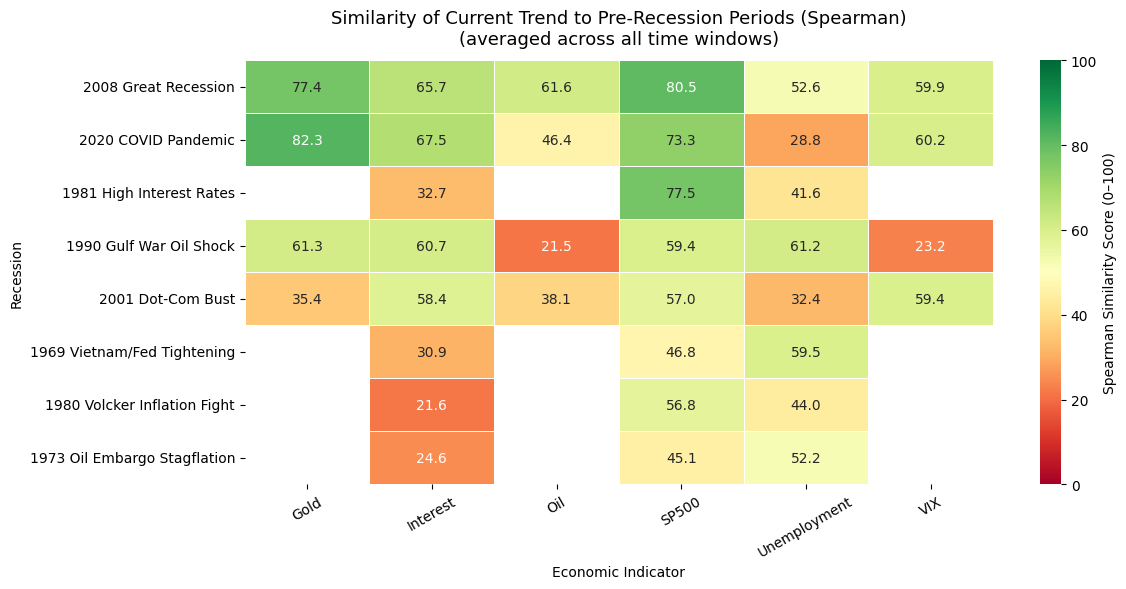

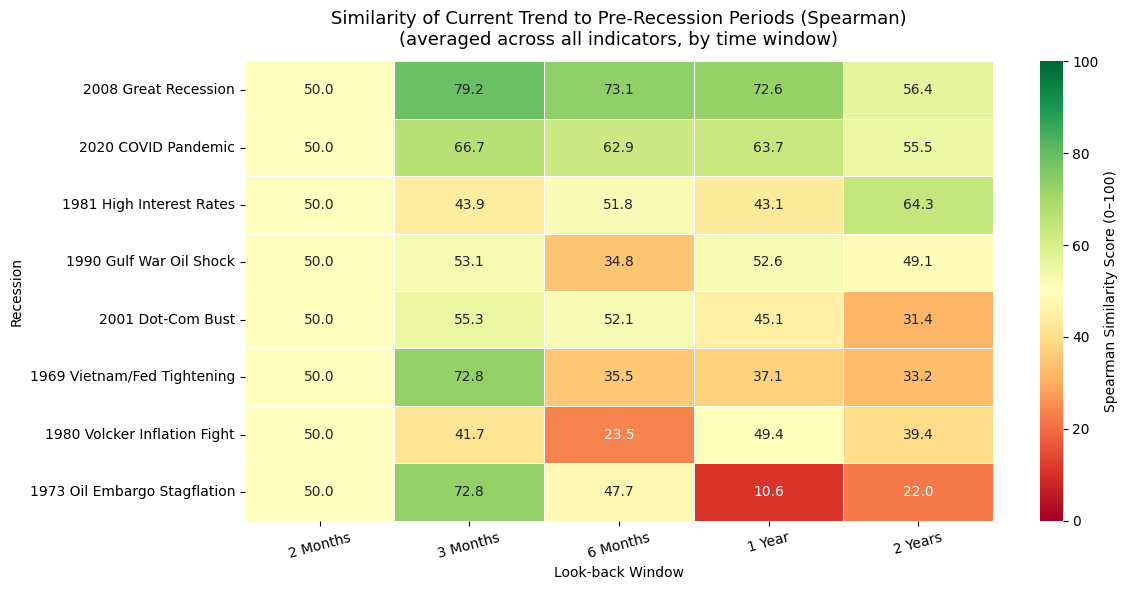

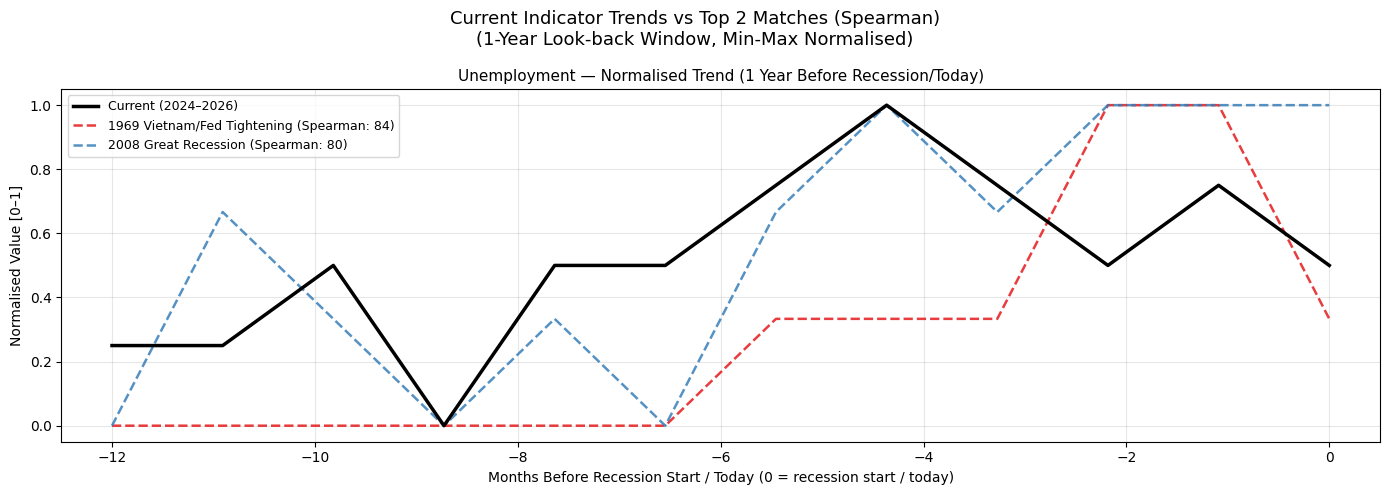

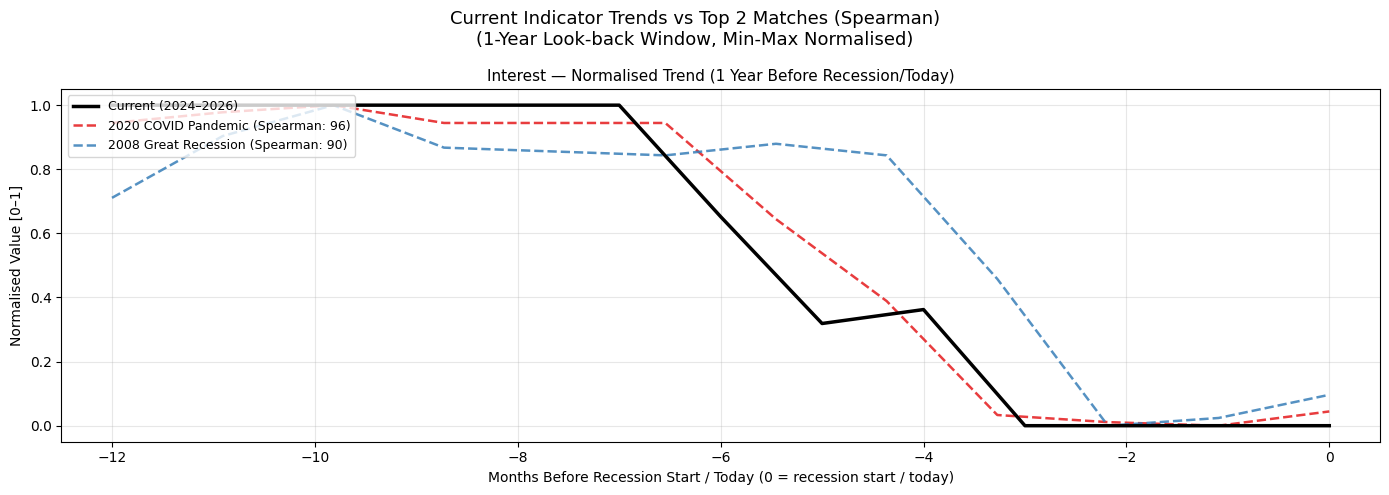

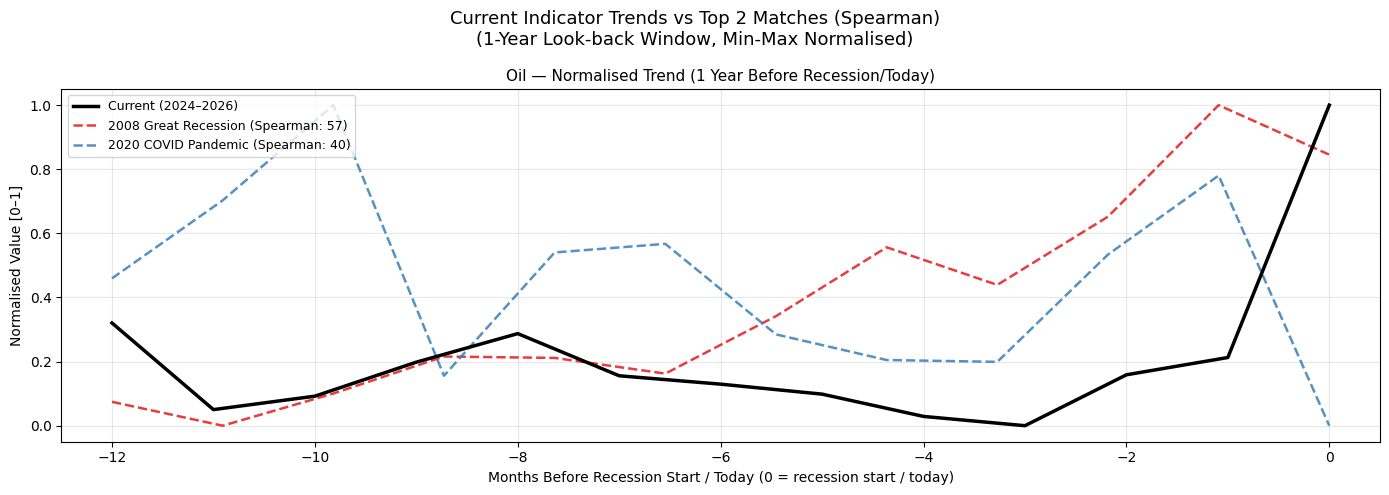

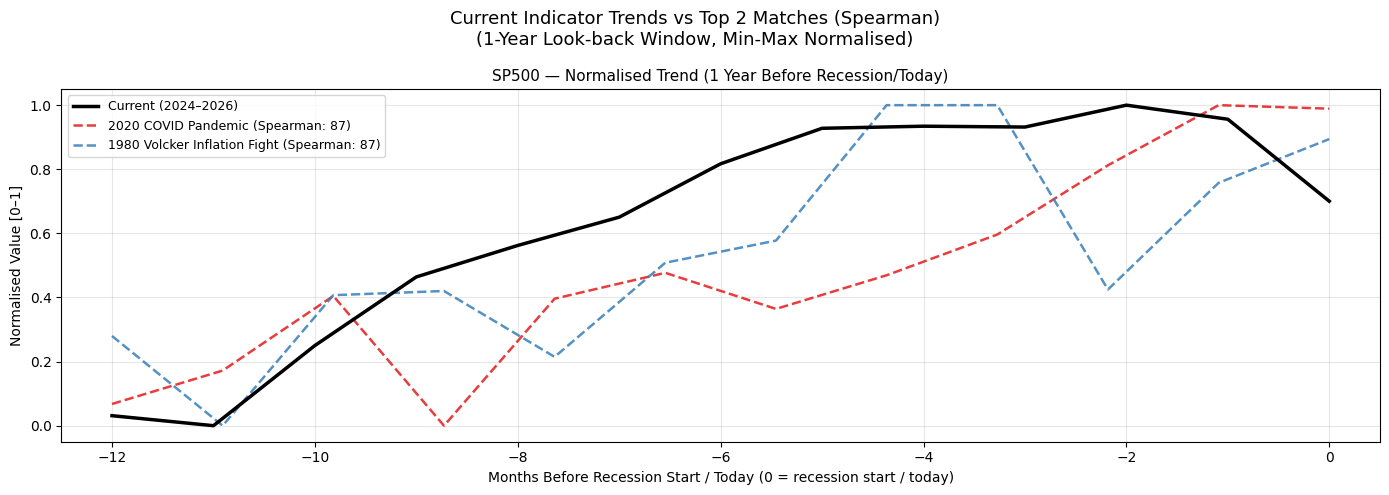

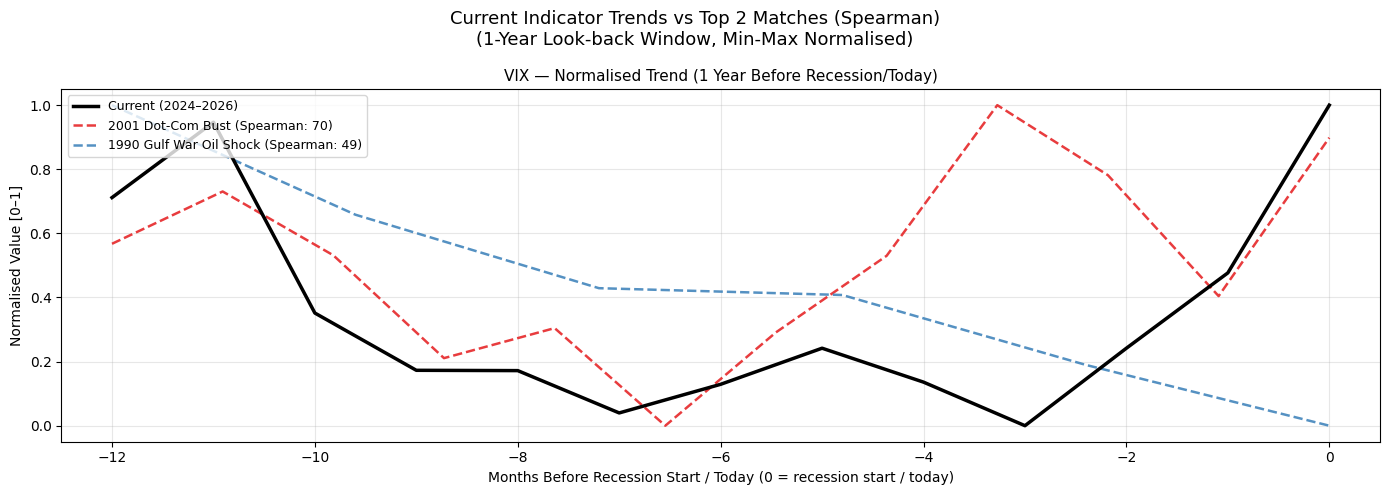

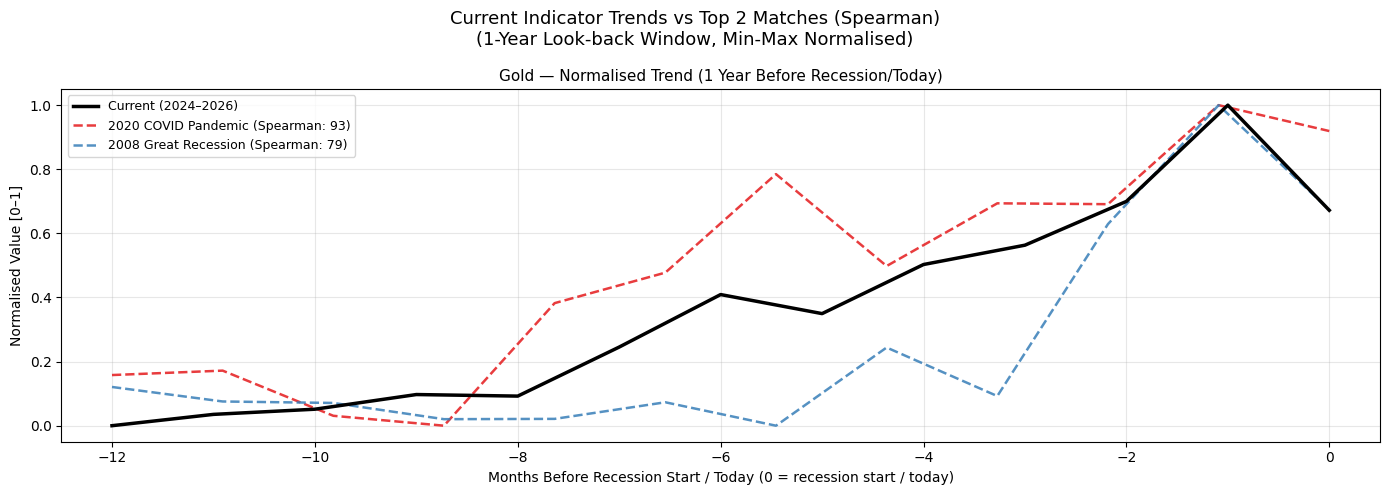

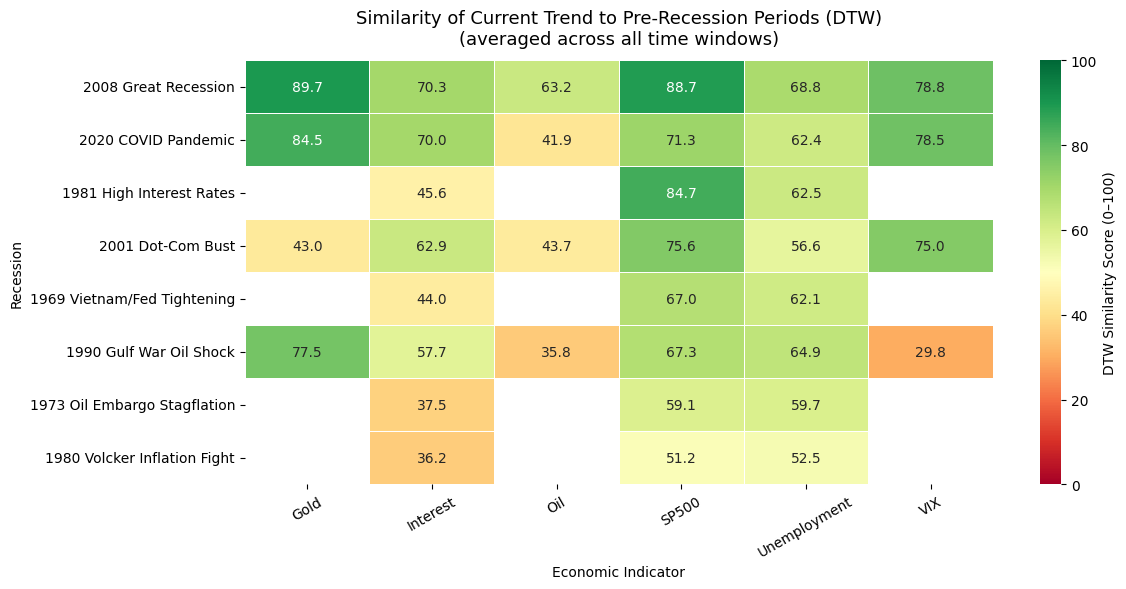

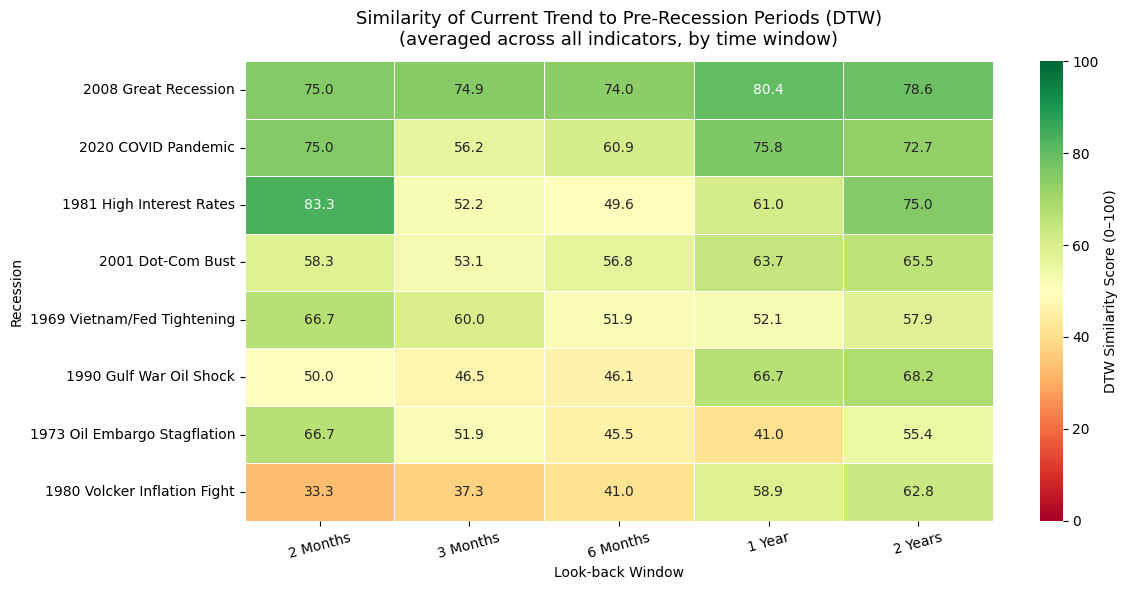

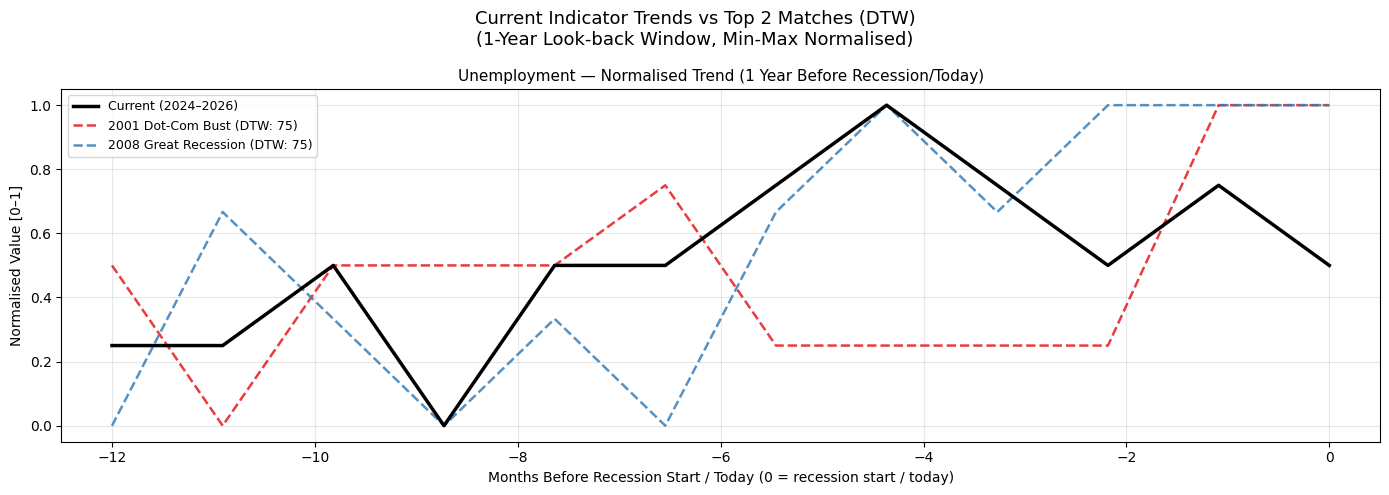

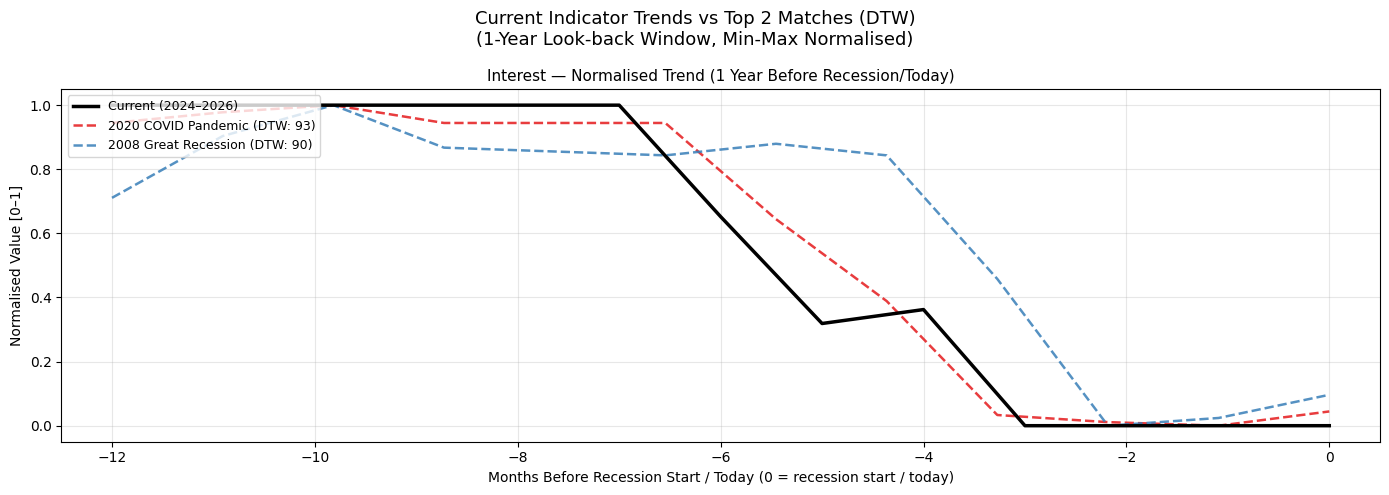

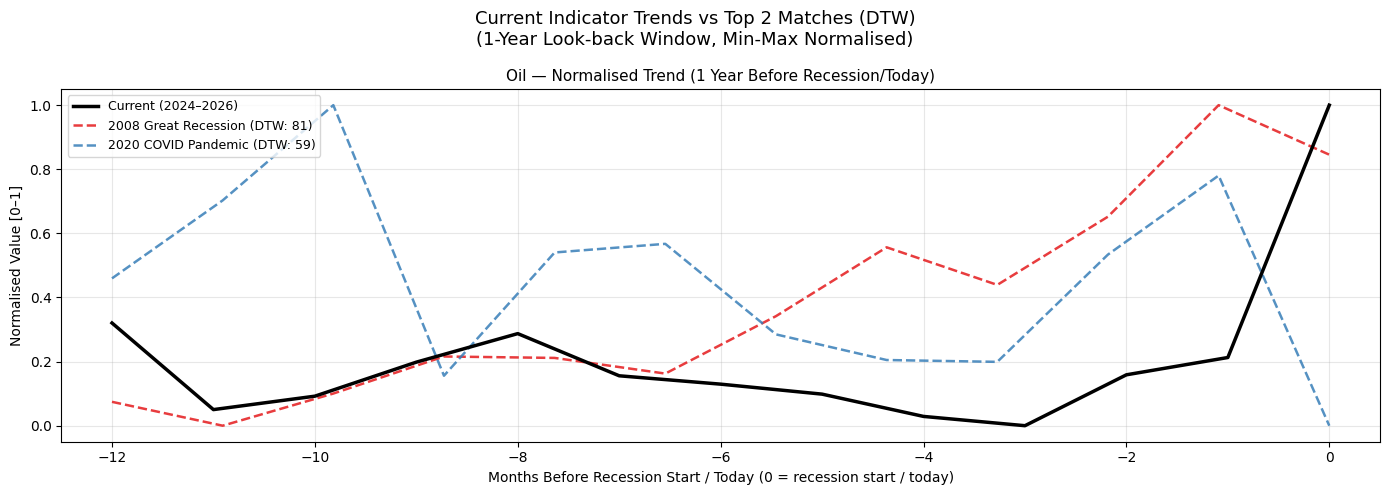

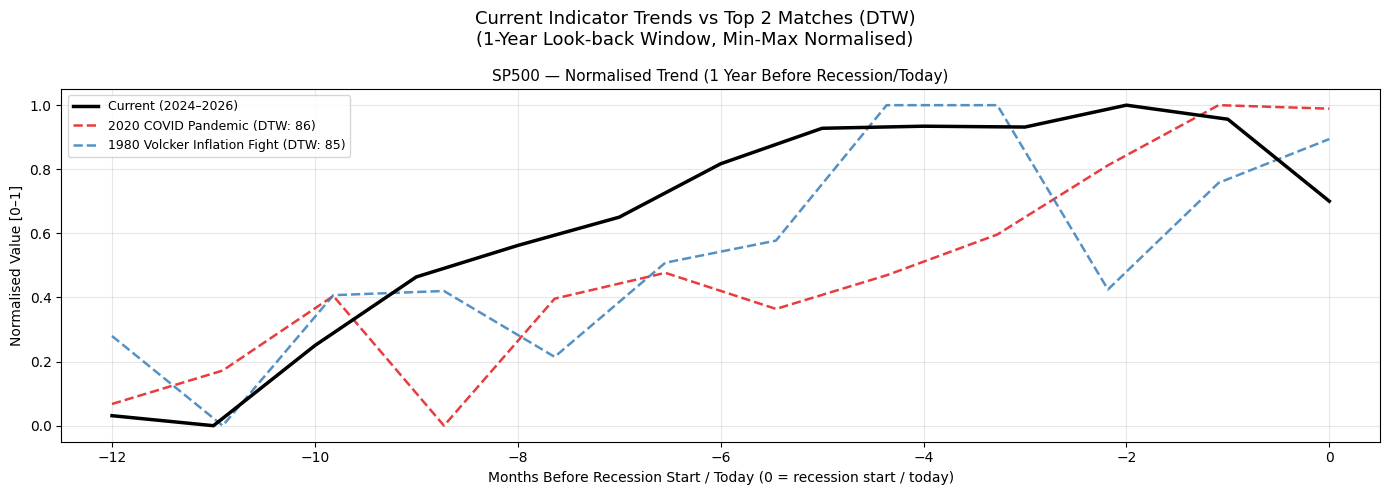

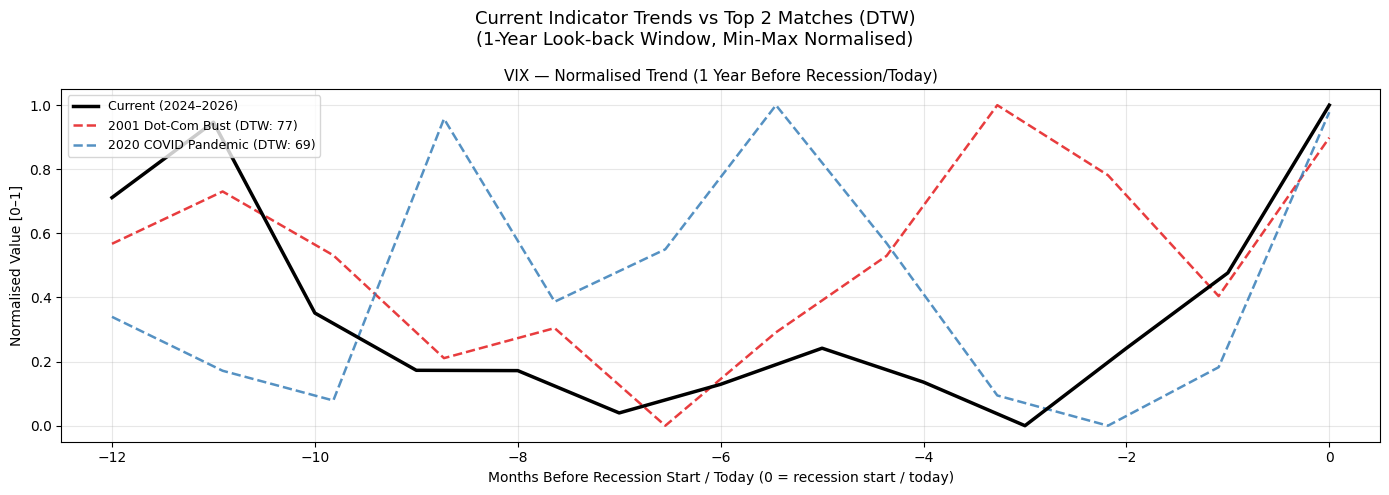

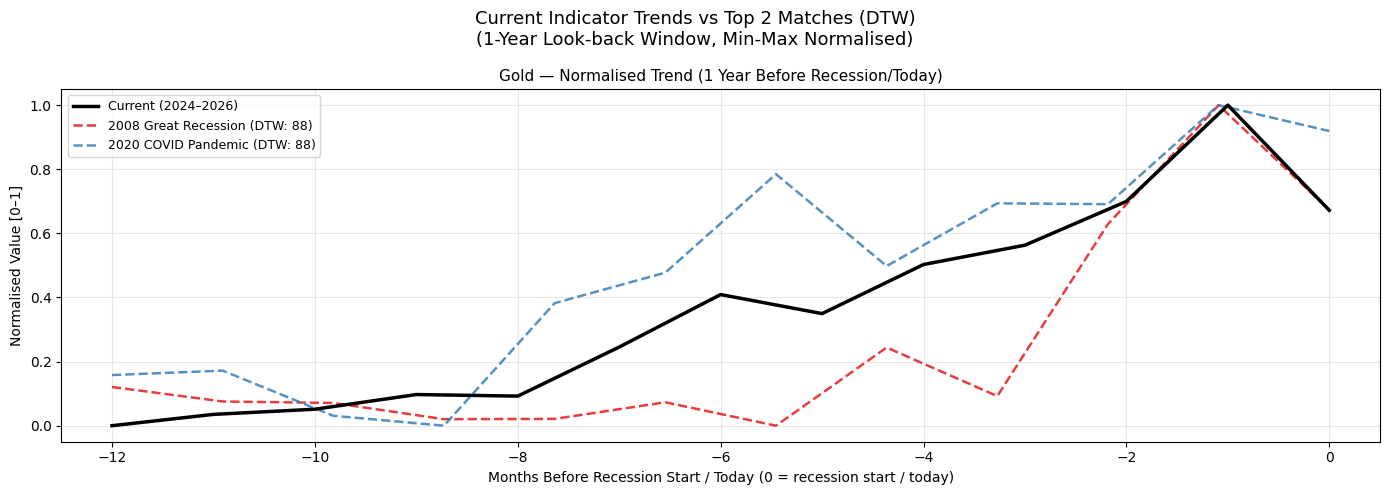


Analysis complete.


In [45]:
if __name__ == "__main__":
    df = load_all_data(FRED_API_KEY)

    print("Computing similarity scores …")
    results = compare_all(df)
    print(f"  ✓ {len(results)} (recession × indicator × window) comparisons completed.\n")

    for metric in ["Spearman", "DTW"]:
        print_top_matches(results, metric=metric)

    print("\n── Full Results Table (top 30 rows) ──")
    display_df = results.sort_values("Spearman", ascending=False).reset_index(drop=True)
    try:
        from IPython.display import display
        display(display_df.head(30))
    except ImportError:
        print(display_df.head(30).to_string(index=False))

    print("\nGenerating plots …")
    for metric in ["Spearman", "DTW"]:
        plot_heatmap(results, metric=metric)
        plot_window_heatmap(results, metric=metric)
        plot_overlay_per_indicator(df, results, metric=metric)

    print("\nAnalysis complete.")

In [44]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

def plot_two_overall_ranking_bars(results: pd.DataFrame):
    """
    Plot two horizontal bar charts ranking recessions by average similarity
    across all indicators and all time windows:
      1) Spearman
      2) DTW
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    metrics = ["Spearman", "DTW"]

    for ax, metric in zip(axes, metrics):
        overall = (
            results.groupby("Recession")[metric]
            .mean()
            .sort_values(ascending=True)
        )

        colors = [
            "#d62728" if score >= SIMILARITY_THRESHOLD else "#aec7e8"
            for score in overall.values
        ]

        bars = ax.barh(overall.index, overall.values, color=colors)

        ax.set_title(
            f"Overall Recession Similarity to Current Economic Trend\n"
            f"({metric}, averaged across all indicators and all time windows)",
            fontsize=13,
            pad=12
        )
        ax.set_xlabel(f"Average {metric} Similarity Score (0–100)")
        ax.set_xlim(0, 105)
        ax.axvline(x=SIMILARITY_THRESHOLD, color="red", linestyle="--", alpha=0.7)

        for bar in bars:
            width = bar.get_width()
            ax.text(
                width + 1,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}",
                ha="left",
                va="center",
                fontsize=10
            )

    notable_patch = mpatches.Patch(
        color="#d62728",
        label=f"Score >= {SIMILARITY_THRESHOLD} (notable)"
    )
    normal_patch = mpatches.Patch(
        color="#aec7e8",
        label=f"Score < {SIMILARITY_THRESHOLD}"
    )
    axes[1].legend(handles=[notable_patch, normal_patch], loc="lower right")

    plt.tight_layout()
    plt.show()

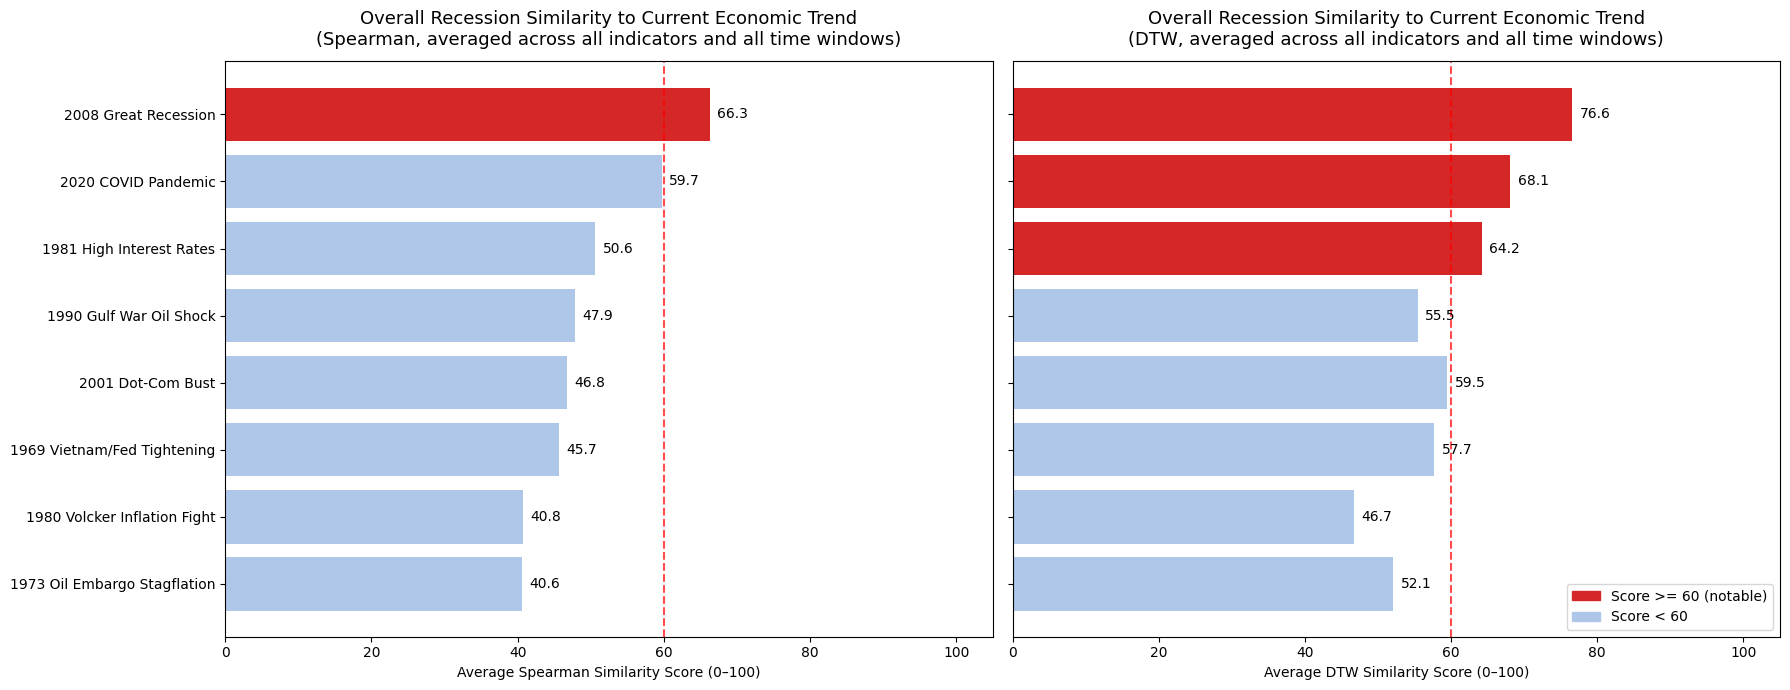

In [46]:
plot_two_overall_ranking_bars(results)